In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('../outputs/customer_rfm.csv')
print("Shape:", df.shape)

# Churned was defined directly from Recency (Recency > 90), so including it
# would leak the target into the features and give artificially perfect scores.

FEATURES=['Frequency','Monetary','AOV','UniqueProducts','Lifespan','AvgDaysBetweenOrders']
TARGET='Churned'

X=df[FEATURES].copy().fillna(0)
y=df[TARGET].copy()

print(f"Features: {FEATURES}")
print(f"\nClass Balance:")
print(y.value_counts())
print(f"Churn Rate: {y.mean()*100:.1f}%")


Shape: (4228, 25)
Features: ['Frequency', 'Monetary', 'AOV', 'UniqueProducts', 'Lifespan', 'AvgDaysBetweenOrders']

Class Balance:
Churned
0    2827
1    1401
Name: count, dtype: int64
Churn Rate: 33.1%


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

print(f"Train set: {X_train.shape[0]} ({y_train.mean()*100:.1f}% churned)")
print(f"Test set: {X_test.shape[0]} ({y_test.mean()*100:.1f}% churned)")


scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.fit_transform(X_test)

X_train_scaled=pd.DataFrame(X_train_scaled, columns=FEATURES, index=X_train.index)
X_test_scaled=pd.DataFrame(X_test_scaled, columns=FEATURES, index=X_test.index)


Train set: 3382 (33.1% churned)
Test set: 846 (33.1% churned)


In [4]:
import os

os.makedirs("../models", exist_ok=True)

with open("../models/scaler_churn.pickle",'wb') as f:
    pickle.dump(scaler,f)

print("Saved scaler_churn.pickle")

Saved scaler_churn.pickle


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score)

lr_model=LogisticRegression(random_state=42,max_iter=1000)
lr_model.fit(X_train_scaled,y_train)

y_pred_lr=lr_model.predict(X_test_scaled)
y_proba_lr=lr_model.predict_proba(X_test_scaled)[:,1]

lr_metrics={
    'Accuracy': accuracy_score(y_test,y_pred_lr),
    'Precision': precision_score(y_test,y_pred_lr),
    'Recall': recall_score(y_test,y_pred_lr),
    'F1': f1_score(y_test,y_pred_lr),
    'AUC': roc_auc_score(y_test,y_proba_lr)
}

print("Logistic Regression results: ")
for k,v in lr_metrics.items():
    print(f"{k}: {v:.4f}")

Logistic Regression results: 
Accuracy: 0.7246
Precision: 0.5719
Recall: 0.6679
F1: 0.6161
AUC: 0.7935


In [6]:
from sklearn.ensemble import RandomForestClassifier

rf_model=RandomForestClassifier(n_estimators=200,max_depth=8,min_samples_split=5,random_state=42,n_jobs=-1)

rf_model.fit(X_train,y_train)
y_pred_rf=rf_model.predict(X_test)
y_proba_rf=rf_model.predict_proba(X_test)[:,1]

rf_metrics={
    'Accuracy': accuracy_score(y_test,y_pred_rf),
    'Precision': precision_score(y_test,y_pred_rf),
    'Recall': recall_score(y_test,y_pred_rf),
    'F1': f1_score(y_test,y_pred_rf),
    'AUC': roc_auc_score(y_test,y_proba_rf)
}

print("Random Forest results:")
for k, v in rf_metrics.items():
    print(f"  {k}: {v:.4f}")


Random Forest results:
  Accuracy: 0.7116
  Precision: 0.5726
  Recall: 0.5071
  F1: 0.5379
  AUC: 0.7983


In [7]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

param_grid={
    'n_estimators': [200,400],
    'max_depth': [3,5,7],
    'learning_rate': [0.01,0.05,0.1],
    'subsample': [0.8,1.0]
}

xgb_base= XGBClassifier(random_state=42, eval_metric='logloss')

grid_search=GridSearchCV(xgb_base,param_grid, cv=3, scoring='roc_auc',n_jobs=-1,verbose=1)

print("Running grid search....")
grid_search.fit(X_train,y_train)

print("\nBest parameters:", grid_search.best_params_)
xgb_model=grid_search.best_estimator_

Running grid search....
Fitting 3 folds for each of 36 candidates, totalling 108 fits

Best parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}


In [8]:
y_pred_xgb=xgb_model.predict(X_test)
y_proba_xgb=xgb_model.predict_proba(X_test)[:,1]

xgb_metrics={
    'Accuracy':  accuracy_score(y_test, y_pred_xgb),
    'Precision': precision_score(y_test, y_pred_xgb),
    'Recall':    recall_score(y_test, y_pred_xgb),
    'F1':        f1_score(y_test, y_pred_xgb),
    'AUC':       roc_auc_score(y_test, y_proba_xgb)
}

print("XGBoost results:")
for k, v in xgb_metrics.items():
    print(f"  {k}: {v:.4f}")

XGBoost results:
  Accuracy: 0.7317
  Precision: 0.6118
  Recall: 0.5179
  F1: 0.5609
  AUC: 0.8081


In [9]:
comparison=pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest','XGBoost'],
    'Accuracy': [lr_metrics['Accuracy'], rf_metrics['Accuracy'],xgb_metrics['Accuracy']],
    'Precision': [lr_metrics['Precision'], rf_metrics['Precision'], xgb_metrics['Precision']],
    'Recall': [lr_metrics['Recall'],rf_metrics['Recall'], xgb_metrics['Recall']],
    'F1': [lr_metrics['F1'],rf_metrics['F1'], xgb_metrics['F1']],
    'AUC': [lr_metrics['AUC'],rf_metrics['AUC'],xgb_metrics['AUC']],
}).round(4)

comparison=comparison.sort_values('AUC',ascending=False)
print(comparison.to_string(index=False))

              Model  Accuracy  Precision  Recall     F1    AUC
            XGBoost    0.7317     0.6118  0.5179 0.5609 0.8081
      Random Forest    0.7116     0.5726  0.5071 0.5379 0.7983
Logistic Regression    0.7246     0.5719  0.6679 0.6161 0.7935


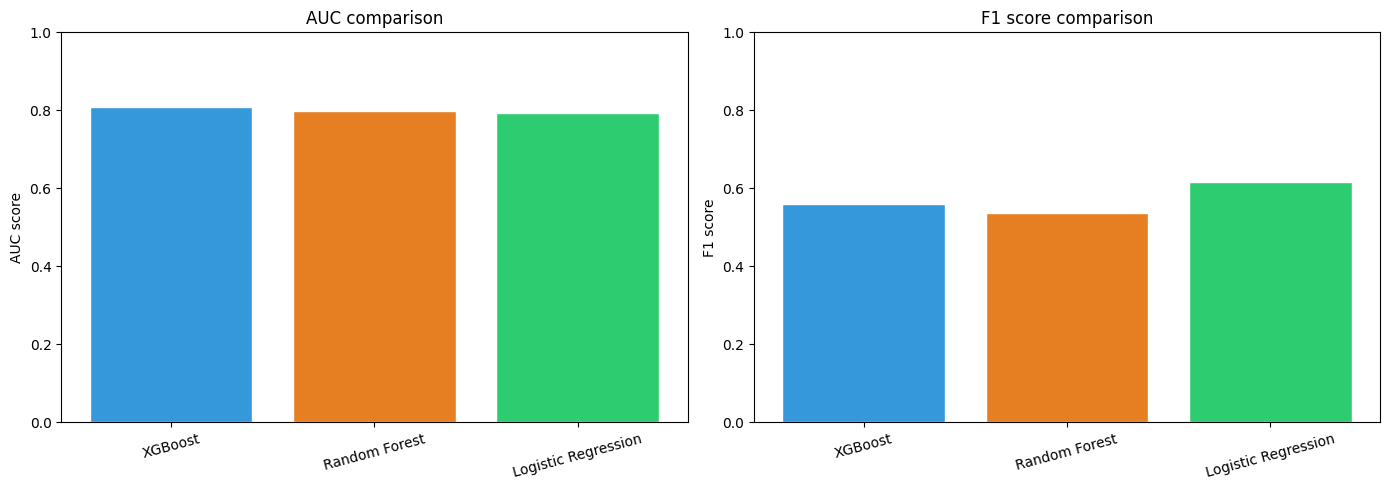

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#3498db', '#e67e22', '#2ecc71']

axes[0].bar(comparison['Model'], comparison['AUC'], color=colors, edgecolor='white')
axes[0].set_title('AUC comparison')
axes[0].set_ylabel('AUC score')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(comparison['Model'], comparison['F1'], color=colors, edgecolor='white')
axes[1].set_title('F1 score comparison')
axes[1].set_ylabel('F1 score')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../outputs/churn_model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

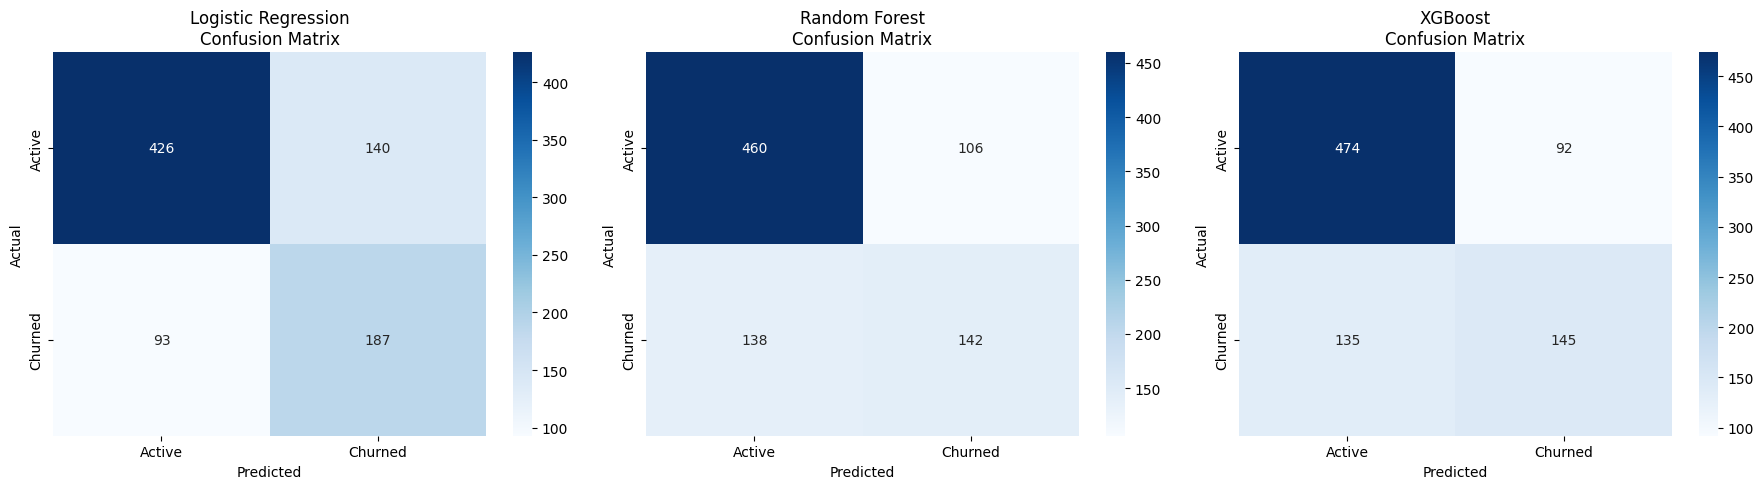

In [11]:
from sklearn.metrics import roc_curve, confusion_matrix

fig,axes=plt.subplots(1,3,figsize=(18,5))

model_preds=[
    ('Logistic Regression', y_pred_lr, '#3498db'),
    ('Random Forest', y_pred_rf, '#e67e22'),
    ('XGBoost',y_pred_xgb, '#2ecc71')
]

for ax, (name,preds,color) in zip(axes, model_preds):
    cm=confusion_matrix(y_test,preds)
    sns.heatmap(cm,annot=True, fmt='d', cmap='Blues',ax=ax, xticklabels=['Active','Churned'], yticklabels=['Active','Churned'])
    ax.set_title(f'{name}\nConfusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('../outputs/churn_confusion_matrix.png',dpi=100,bbox_inches='tight')
plt.show()
    

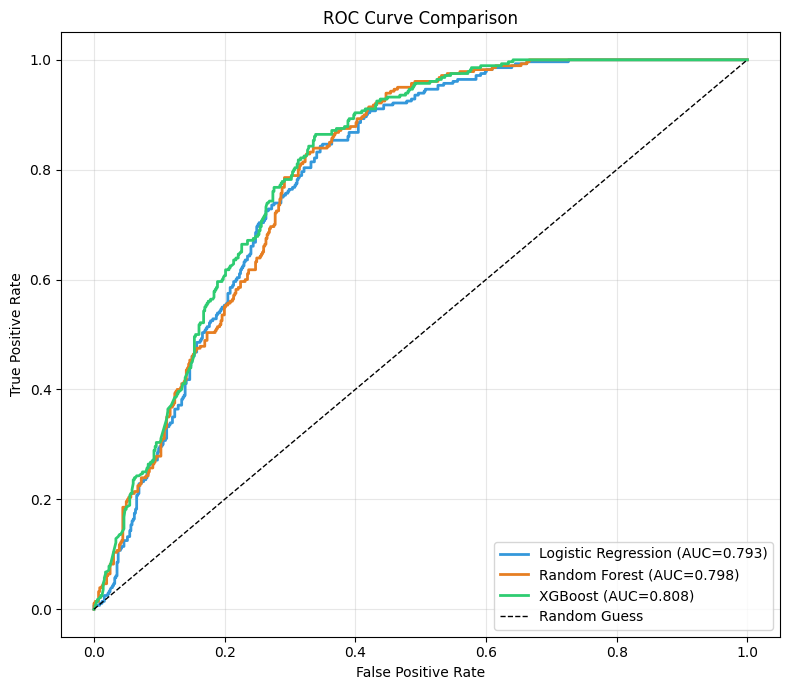

In [12]:
plt.figure(figsize=(8,7))

for name, proba,color in [
    ('Logistic Regression', y_proba_lr, '#3498db'),
    ('Random Forest', y_proba_rf, '#e67e22'),
    ('XGBoost', y_proba_xgb, '#2ecc71')
]:
    fpr,tpr,_=roc_curve(y_test,proba)
    auc=roc_auc_score(y_test,proba)
    plt.plot(fpr,tpr,color=color,linewidth=2,label=f'{name} (AUC={auc:.3f})')
    
plt.plot([0,1],[0,1],'k--',linewidth=1,label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/churn_roc_curves.png',dpi=100,bbox_inches='tight')
plt.show()

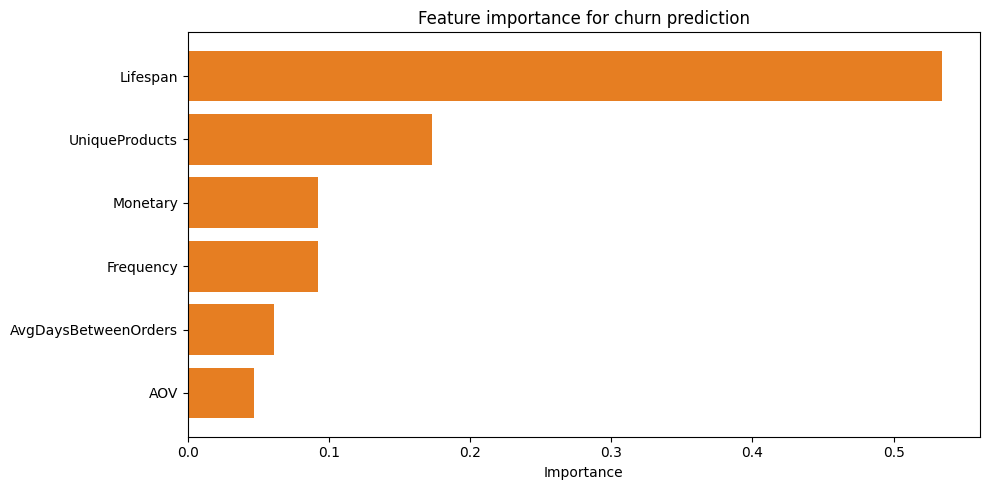

             Feature  Importance
            Lifespan    0.534451
      UniqueProducts    0.173118
            Monetary    0.092259
           Frequency    0.092066
AvgDaysBetweenOrders    0.061090
                 AOV    0.047017


In [13]:
importance=pd.DataFrame({
    'Feature': FEATURES,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(importance['Feature'], importance['Importance'], color='#e67e22')
plt.xlabel('Importance')
plt.title('Feature importance for churn prediction')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../outputs/churn_feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

print(importance.to_string(index=False))

In [14]:
best_row=comparison.iloc[0]
best_model_name=best_row['Model']

print(f'Best model by AUC: {best_model_name}')
print(f"AUC: {best_row['AUC']:.4f}")
print(f"F1: {best_row['F1']:.4f}")
print(f"Precision: {best_row['Precision']:.4f}")
print(f"Recall: {best_row['Recall']:.4f}")

model_map={
    'Logistic Regression': lr_model,
    'Random Forest': rf_model,
    'XGBoost': xgb_model

}
best_churn_model=model_map[best_model_name]

needs_scaling=best_model_name=='Logistic Regression'

Best model by AUC: XGBoost
AUC: 0.8081
F1: 0.5609
Precision: 0.6118
Recall: 0.5179


In [15]:
X_full=df[FEATURES].fillna(0)

if needs_scaling:
    X_full_input=scaler.transform(X_full)
else:
    X_full_input=X_full
    
df['Churn_Probability']=best_churn_model.predict_proba(X_full_input)[:,1]

df['Churn_Risk']=pd.cut(
    df['Churn_Probability'], bins=[0,0.3,0.6,1.0], labels=['Low','Medium','High']
)

print(df[['CustomerID','Churn_Probability','Churn_Risk']].head(10))
print("\nRisk tier distribution:")
print(df['Churn_Risk'].value_counts())


   CustomerID  Churn_Probability Churn_Risk
0       12347           0.047957        Low
1       12348           0.498511     Medium
2       12349           0.395317     Medium
3       12350           0.548192     Medium
4       12352           0.116130        Low
5       12353           0.580602     Medium
6       12354           0.397558     Medium
7       12355           0.559497     Medium
8       12356           0.047957        Low
9       12357           0.353451     Medium

Risk tier distribution:
Churn_Risk
Medium    2416
Low       1759
High        53
Name: count, dtype: int64


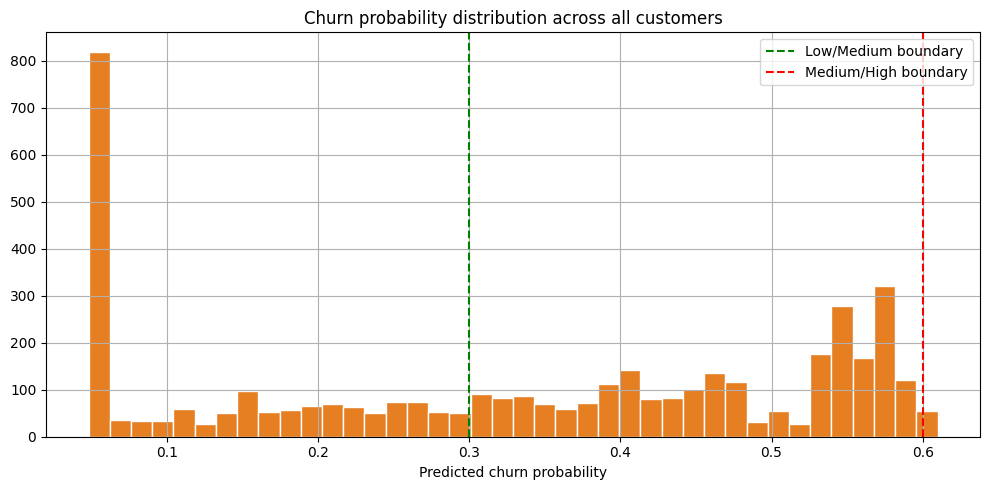

In [16]:
plt.figure(figsize=(10, 5))
df['Churn_Probability'].hist(bins=40, color='#e67e22', edgecolor='white')
plt.axvline(0.3, color='green', linestyle='--', label='Low/Medium boundary')
plt.axvline(0.6, color='red', linestyle='--', label='Medium/High boundary')
plt.title('Churn probability distribution across all customers')
plt.xlabel('Predicted churn probability')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/churn_probability_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

In [18]:
with open('../models/churn_model.pickle','wb') as f:
    pickle.dump(best_churn_model, f)
with open('../models/churn_features.pickle','wb') as f:
    pickle.dump(FEATURES,f)

comparison.to_csv('../outputs/churn_model_comparison_table.csv',index=False)

df.to_csv('../outputs/customer_rfm.csv',index=False)

print("Saved:")
print("models/churn_model.pickle")
print("models/churn_features.pickle")
print("outputs/churn_model_comparison_table.csv")
print("outputs/customer_rfm.csv (updated with Churn_Probability, Churn_Risk)")
print(f"\nWinning model: {best_model_name}")


Saved:
models/churn_model.pickle
models/churn_features.pickle
outputs/churn_model_comparison_table.csv
outputs/customer_rfm.csv (updated with Churn_Probability, Churn_Risk)

Winning model: XGBoost
